In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r"C:\Users\DELL\Documents\wmgmt.csv")
df

,area,ticket_date,waste_type,net_weight_kg
0,Boralesgamuwa UC,01-01-2012,MSW,17340
1,Boralesgamuwa UC,02-01-2012,MSW,25980
2,Boralesgamuwa UC,03-01-2012,MSW,29220
3,Boralesgamuwa UC,04-01-2012,MSW,7450
4,Boralesgamuwa UC,05-01-2012,MSW,10520
...,...,...,...,...
6566,Dehiwala MC,30-12-2018,MSW,116620
6567,Dehiwala MC,30-12-2018,Non Biodegradable,2410
6568,Dehiwala MC,31-12-2018,Biodegradable,135300
6569,Dehiwala MC,31-12-2018,MSW,56770


In [4]:
df.head(10)

,area,ticket_date,waste_type,net_weight_kg
0,Boralesgamuwa UC,01-01-2012,MSW,17340
1,Boralesgamuwa UC,02-01-2012,MSW,25980
2,Boralesgamuwa UC,03-01-2012,MSW,29220
3,Boralesgamuwa UC,04-01-2012,MSW,7450
4,Boralesgamuwa UC,05-01-2012,MSW,10520
5,Boralesgamuwa UC,06-01-2012,MSW,29260
6,Boralesgamuwa UC,07-01-2012,MSW,11820
7,Boralesgamuwa UC,08-01-2012,MSW,20680
8,Boralesgamuwa UC,09-01-2012,MSW,23940
9,Boralesgamuwa UC,10-01-2012,MSW,23330


In [5]:
df.tail(10)

,area,ticket_date,waste_type,net_weight_kg
6561,Dehiwala MC,28-12-2018,MSW,18630
6562,Dehiwala MC,28-12-2018,Non Biodegradable,1790
6563,Dehiwala MC,29-12-2018,Biodegradable,9380
6564,Dehiwala MC,29-12-2018,MSW,169950
6565,Dehiwala MC,29-12-2018,Non Biodegradable,3420
6566,Dehiwala MC,30-12-2018,MSW,116620
6567,Dehiwala MC,30-12-2018,Non Biodegradable,2410
6568,Dehiwala MC,31-12-2018,Biodegradable,135300
6569,Dehiwala MC,31-12-2018,MSW,56770
6570,Dehiwala MC,31-12-2018,Non Biodegradable,1390


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6571 entries, 0 to 6570
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   area           6571 non-null   str  
 1   ticket_date    6571 non-null   str  
 2   waste_type     6571 non-null   str  
 3   net_weight_kg  6571 non-null   int64
dtypes: int64(1), str(3)
memory usage: 205.5 KB


In [7]:
df.describe()

,net_weight_kg
count,6571.000000
mean,56011.736418
std,61527.761084
min,0.000000
25%,8585.000000
50%,27450.000000
75%,112455.000000
max,394870.000000


In [8]:
df['ticket_date'] = pd.to_datetime(df['ticket_date'], dayfirst=True)
df



,area,ticket_date,waste_type,net_weight_kg
0,Boralesgamuwa UC,2012-01-01,MSW,17340
1,Boralesgamuwa UC,2012-01-02,MSW,25980
2,Boralesgamuwa UC,2012-01-03,MSW,29220
3,Boralesgamuwa UC,2012-01-04,MSW,7450
4,Boralesgamuwa UC,2012-01-05,MSW,10520
...,...,...,...,...
6566,Dehiwala MC,2018-12-30,MSW,116620
6567,Dehiwala MC,2018-12-30,Non Biodegradable,2410
6568,Dehiwala MC,2018-12-31,Biodegradable,135300
6569,Dehiwala MC,2018-12-31,MSW,56770


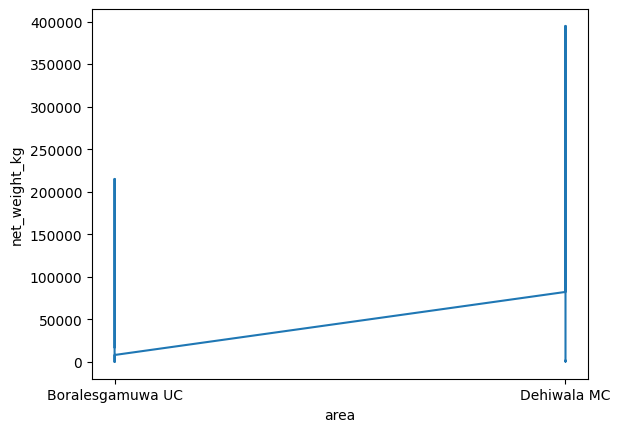

In [9]:
plt.plot(df["area"],df["net_weight_kg"])
plt.xlabel("area")
plt.ylabel("net_weight_kg")
plt.show()

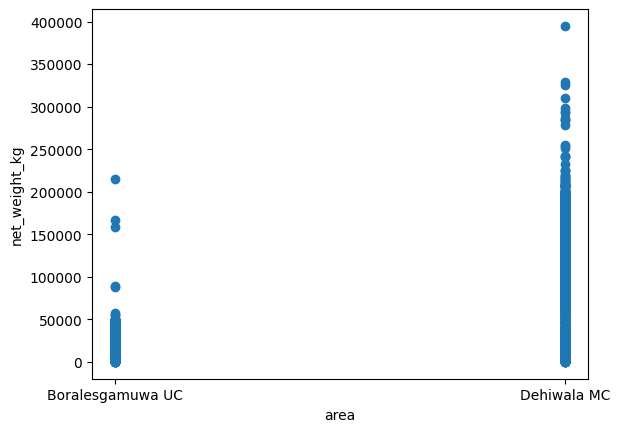

In [10]:
plt.scatter(df["area"],df["net_weight_kg"])
plt.xlabel("area")
plt.ylabel("net_weight_kg")
plt.show()

In [11]:
from scipy.stats import kstest
import numpy as np

# Normalize data to [0,1] for uniform test
data = (df['net_weight_kg'] - df['net_weight_kg'].min()) / (
    df['net_weight_kg'].max() - df['net_weight_kg'].min()
)

stat, p_value = kstest(data, 'uniform')
print("p-value:", p_value)

p-value: 0.0


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


In [13]:
df['year'] = df['ticket_date'].dt.year
df['month'] = df['ticket_date'].dt.month
df['day'] = df['ticket_date'].dt.day
df['dayofweek'] = df['ticket_date'].dt.dayofweek
df

,area,ticket_date,waste_type,net_weight_kg,year,month,day,dayofweek
0,Boralesgamuwa UC,2012-01-01,MSW,17340,2012,1,1,6
1,Boralesgamuwa UC,2012-01-02,MSW,25980,2012,1,2,0
2,Boralesgamuwa UC,2012-01-03,MSW,29220,2012,1,3,1
3,Boralesgamuwa UC,2012-01-04,MSW,7450,2012,1,4,2
4,Boralesgamuwa UC,2012-01-05,MSW,10520,2012,1,5,3
...,...,...,...,...,...,...,...,...
6566,Dehiwala MC,2018-12-30,MSW,116620,2018,12,30,6
6567,Dehiwala MC,2018-12-30,Non Biodegradable,2410,2018,12,30,6
6568,Dehiwala MC,2018-12-31,Biodegradable,135300,2018,12,31,0
6569,Dehiwala MC,2018-12-31,MSW,56770,2018,12,31,0


In [14]:
df = df.sort_values('ticket_date')
df['lag_1'] = df['net_weight_kg'].shift(1)

df = df.dropna()
df


,area,ticket_date,waste_type,net_weight_kg,year,month,day,dayofweek,lag_1
2988,Dehiwala MC,2012-01-01,Non Biodegradable,82270,2012,1,1,6,17340.0
2989,Dehiwala MC,2012-01-02,Non Biodegradable,123010,2012,1,2,0,82270.0
1,Boralesgamuwa UC,2012-01-02,MSW,25980,2012,1,2,0,123010.0
2,Boralesgamuwa UC,2012-01-03,MSW,29220,2012,1,3,1,25980.0
2990,Dehiwala MC,2012-01-03,Non Biodegradable,128330,2012,1,3,1,29220.0
...,...,...,...,...,...,...,...,...,...
6568,Dehiwala MC,2018-12-31,Biodegradable,135300,2018,12,31,0,116620.0
2987,Boralesgamuwa UC,2018-12-31,Sorted Organic Waste,8150,2018,12,31,0,135300.0
2986,Boralesgamuwa UC,2018-12-31,MSW,40420,2018,12,31,0,8150.0
6569,Dehiwala MC,2018-12-31,MSW,56770,2018,12,31,0,40420.0


In [15]:
X = df[['year', 'month', 'day', 'dayofweek', 'lag_1']]
y = df['net_weight_kg']



In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


In [18]:
print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))


Linear Regression
MAE: 36876.31632101091
RMSE: 50859.63316223595
R2: 0.018526560796666036


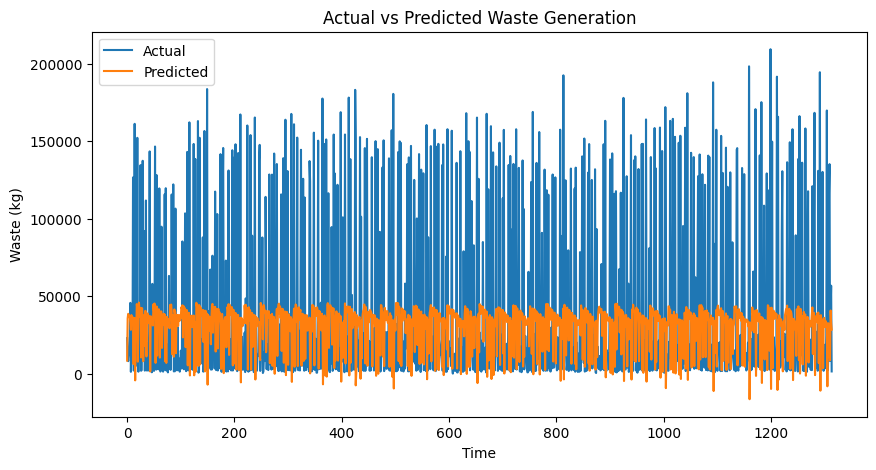

In [19]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_lr, label="Predicted")
plt.xlabel("Time")
plt.ylabel("Waste (kg)")
plt.title("Actual vs Predicted Waste Generation")
plt.legend()
plt.show()